# **Week 2. Supervised Learning**

2주차 과제는 지도학습의 회귀, 분류 모델을 학습-평가하는 과정을 간소하게 재현한 코드입니다.

1. 적힌 코드를 따라가며, 배운 내용과 어떻게 연관되는지 등을 생각하거나 찾아본 후, 주석으로 달아주시면 좋을 것 같습니다.
2. 더불어 생각해볼 만한 질문들을 중간에 달아두었으니, 이에 대한 고민과 답변을 작성해주시면 됩니다.

# **1. 회귀 - with diabetes dataset**

In [3]:
# 필요한 패키지 설치하기

%pip install -q numpy pandas scikit-learn seaborn matplotlib

Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 26.1.1 -> 26.1.2
[notice] To update, run: python.exe -m pip install --upgrade pip


In [4]:
# 필요한 라이브러리 불러오기
import numpy as np
import pandas as pd
from sklearn.datasets import load_diabetes
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score

import seaborn as sns
import matplotlib.pyplot as plt

## 1. 데이터 로드 및 탐색

In [ ]:
diabetes = load_diabetes()               # scikit-learn에서 제공하는 당뇨병 데이터셋 불러오기
X, y = diabetes.data, diabetes.target    # X: 입력 피쳐, y: 예측하려는 타겟 -> X를 이용해서 y를 예측
feature_names = diabetes.feature_names   # 각 피쳐의 이름

In [ ]:
# 데이터 크기와 피처(특성) 정보 출력
print(f"Dataset Shape: {X.shape}")                     # ( 행 개수 , 열 개수 )
print(f"Feature Names: {diabetes.feature_names}")      
print(f"Target (y) Sample: {y[:5]}")                   # 타겟 값 일부 확인

Dataset Shape: (442, 10)
Feature Names: ['age', 'sex', 'bmi', 'bp', 's1', 's2', 's3', 's4', 's5', 's6']
Target (y) Sample: [151.  75. 141. 206. 135.]


In [8]:
# 데이터프레임으로 변환하여 탐색
df = pd.DataFrame(X, columns=feature_names)  # 현재 X는 numpy 배열 -> 데이터프레임으로 변환
df['target'] = y

In [ ]:
df.info()      # 데이터의 기본 구조 확인 : 행 개수 / 열 개수 / 각 열의 데이터 타입 / 결측치 여부 등

<class 'pandas.DataFrame'>
RangeIndex: 442 entries, 0 to 441
Data columns (total 11 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   age     442 non-null    float64
 1   sex     442 non-null    float64
 2   bmi     442 non-null    float64
 3   bp      442 non-null    float64
 4   s1      442 non-null    float64
 5   s2      442 non-null    float64
 6   s3      442 non-null    float64
 7   s4      442 non-null    float64
 8   s5      442 non-null    float64
 9   s6      442 non-null    float64
 10  target  442 non-null    float64
dtypes: float64(11)
memory usage: 38.1 KB


In [ ]:
df.describe()      # 각 변수의 기초 통계량

,age,sex,bmi,bp,s1,s2,s3,s4,s5,s6,target
count,4.420000e+02,4.420000e+02,4.420000e+02,4.420000e+02,4.420000e+02,4.420000e+02,4.420000e+02,4.420000e+02,4.420000e+02,4.420000e+02,442.000000
mean,-2.511817e-19,1.230790e-17,-2.245564e-16,-4.797570e-17,-1.381499e-17,3.918434e-17,-5.777179e-18,-9.042540e-18,9.293722e-17,1.130318e-17,152.133484
std,4.761905e-02,4.761905e-02,4.761905e-02,4.761905e-02,4.761905e-02,4.761905e-02,4.761905e-02,4.761905e-02,4.761905e-02,4.761905e-02,77.093005
min,-1.072256e-01,-4.464164e-02,-9.027530e-02,-1.123988e-01,-1.267807e-01,-1.156131e-01,-1.023071e-01,-7.639450e-02,-1.260971e-01,-1.377672e-01,25.000000
25%,-3.729927e-02,-4.464164e-02,-3.422907e-02,-3.665608e-02,-3.424784e-02,-3.035840e-02,-3.511716e-02,-3.949338e-02,-3.324559e-02,-3.317903e-02,87.000000
50%,5.383060e-03,-4.464164e-02,-7.283766e-03,-5.670422e-03,-4.320866e-03,-3.819065e-03,-6.584468e-03,-2.592262e-03,-1.947171e-03,-1.077698e-03,140.500000
75%,3.807591e-02,5.068012e-02,3.124802e-02,3.564379e-02,2.835801e-02,2.984439e-02,2.931150e-02,3.430886e-02,3.243232e-02,2.791705e-02,211.500000
max,1.107267e-01,5.068012e-02,1.705552e-01,1.320436e-01,1.539137e-01,1.987880e-01,1.811791e-01,1.852344e-01,1.335973e-01,1.356118e-01,346.000000


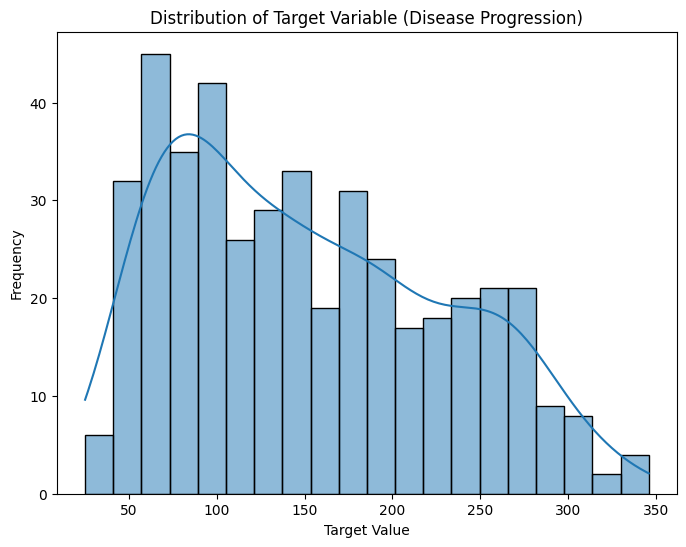

In [ ]:
# 히스토그램으로 타겟 값 분포 확인 : 특정 구간에 값이 몰려있는지, 유난히 큰 값이 있는지 등 분포 확인
plt.figure(figsize=(8, 6))      # 그래프 크기 설정
sns.histplot(df['target'], bins=20, kde=True)  # target 값의 히스토그램과 커널 밀도 추정(KDE) 곡선 그리기
plt.title("Distribution of Target Variable (Disease Progression)")
plt.xlabel("Target Value")
plt.ylabel("Frequency")
plt.show()

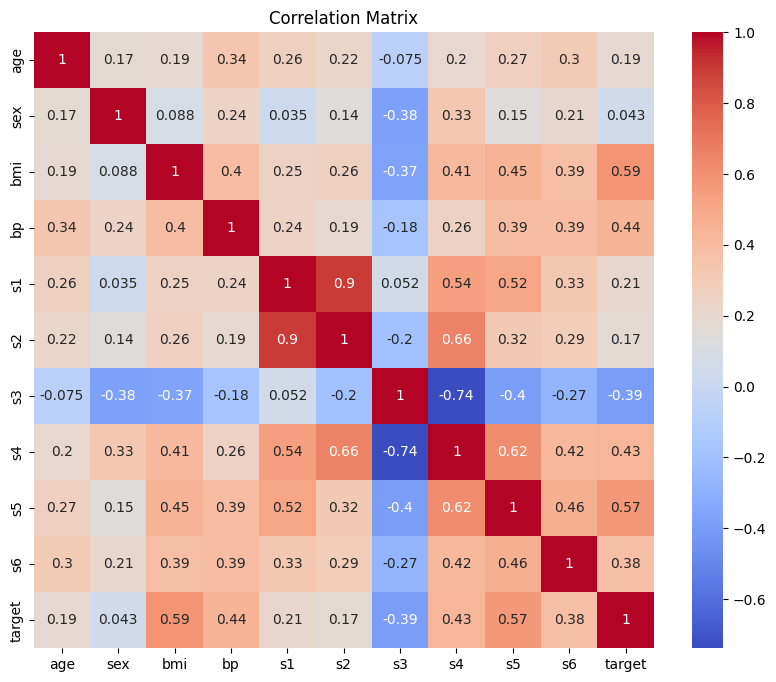

In [ ]:
# 상관 행렬 및 히트맵 시각화
plt.figure(figsize=(10, 8))
correlation_matrix = df.corr()     # 변수 간 상관계수 계산
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm')  # 히트맵 그리기
plt.title("Correlation Matrix")
plt.show()

In [10]:
# Q1-1: 어떤 피처(특성)가 가장 중요한지, 직접 데이터를 분석해보세요.
# Q1-2: 어떤 피처가 'target'과 가장 높은 상관관계를 가지나요?

In [12]:
# Q1-1: 
# target과 각 피처 사이의 상관계수만 추출
target_correlation = correlation_matrix['target'].drop('target') 
# 상관계수의 절댓값이 큰 순서대로 정렬 (내림차순)
target_correlation_sorted = target_correlation.sort_values(ascending=False)
print(target_correlation_sorted)


bmi    0.586450
s5     0.565883
bp     0.441482
s4     0.430453
s6     0.382483
s1     0.212022
age    0.187889
s2     0.174054
sex    0.043062
s3    -0.394789
Name: target, dtype: float64


In [ ]:
# Q1-2: 히트맵에서 마지막 열 = target과 각 피처 간의 상관계수
# 히트맵에서도, 직접 상관계수를 내림차순으로 정렬해보았을 때도 bmi가 가장 target과 상관계수가 높다.
# 따라서 bmi가 target과 가장 높은 상관관계를 가지고, 중요한 변수로 고려될 수 있다.

## 2. 데이터 전처리: 데이터 분할 및 스케일링


In [19]:
# 훈련 데이터와 테스트 데이터 분할 : 80%는 훈련용, 20%는 테스트용으로 분할
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [ ]:
# Q2: 데이터 분할 비율을 70:30 또는 90:10으로 변경하면 결과는 어떻게 달라질까요?
# 결과 = 모델의 테스트 성능 ( MSE, R^2점수 등 ) 이라고 생각하면, 다음과 같은 결과가 나온다.

# 데이터 분할 비율 : 70:30 -> test_size=0.3
X_train_70, X_test_70, y_train_70, y_test_70 = train_test_split(X, y, test_size=0.3, random_state=42)

# 데이터 분할 비율 : 90:10 -> test_size=0.1
X_train_90, X_test_90, y_train_90, y_test_90 = train_test_split(X, y, test_size=0.1, random_state=42)   

# 80:20 분할
model_80 = LinearRegression()
model_80.fit(X_train, y_train)
y_pred_80 = model_80.predict(X_test)
mse_80 = mean_squared_error(y_test, y_pred_80)
r2_80 = r2_score(y_test, y_pred_80)

# 70:30 분할
model_70 = LinearRegression()
model_70.fit(X_train_70, y_train_70)
y_pred_70 = model_70.predict(X_test_70)
mse_70 = mean_squared_error(y_test_70, y_pred_70)
r2_70 = r2_score(y_test_70, y_pred_70)

# 90:10 분할
model_90 = LinearRegression()
model_90.fit(X_train_90, y_train_90)
y_pred_90 = model_90.predict(X_test_90)
mse_90 = mean_squared_error(y_test_90, y_pred_90)
r2_90 = r2_score(y_test_90, y_pred_90)

# 결과 출력
print(f"80:20 분할 - MSE: {mse_80:.2f}, R^2: {r2_80:.2f}")  # 소수점 둘째자리까지 출력
print(f"70:30 분할 - MSE: {mse_70:.2f}, R^2: {r2_70:.2f}")
print(f"90:10 분할 - MSE: {mse_90:.2f}, R^2: {r2_90:.2f}")


80:20 분할 - MSE: 2900.19, R^2: 0.45
70:30 분할 - MSE: 2821.75, R^2: 0.48
90:10 분할 - MSE: 2743.91, R^2: 0.55


In [ ]:
# 결괏값에 의하면, 이 셋 중에서는 90:10 분할의 MSE가 가장 낮고, R^2 점수가 가장 높다.
# 훈련데이터의 비율이 높아지면 더 많은 데이터를 학습할 수 있지만, 테스트 데이터의 비율이 낮아지기 때문에 평가결과가 우연에 의해 크게 달라질 수 있다.
# 따라서 90:10 분할이 최적의 분할이라고 단정하기는 어렵다.

In [24]:
# 스케일링(표준화) : 피처들의 숫자 범위를 비슷하게 맞춰주기
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)  # 훈련 데이터의 평균과 표준편차를 계산하고 변환
X_test = scaler.transform(X_test)        # 테스트 데이터는 평균과 표준편차를 계산하지 않고, 훈련 데이터에서 구한 기준으로 변환만 진행

In [ ]:
# Q3: 스케일링을 하지 않고 학습하면 어떤 결과가 나올까요? 한 번 실험해 보세요.

# 스케일링하지 않은 데이터로 선형회귀 학습
X_train_raw = X_train.copy()  # 스케일링하지 않은 원본 데이터를 사용
X_test_raw = X_test.copy()    # 스케일링하지 않은 원본 데이터를 사용

unscaled_model = LinearRegression()
unscaled_model.fit(X_train_raw, y_train)
unscaled_y_pred = unscaled_model.predict(X_test_raw)

# 모델 성능 평가
unscaled_mse = mean_squared_error(y_test, unscaled_y_pred)
unscaled_r2 = r2_score(y_test, unscaled_y_pred)

# 결과 출력
print(f"Unscaled MSE : {unscaled_mse:.2f}, R^2: {unscaled_r2:.2f}")


# 스케일링한 데이터로 선형회귀 학습
scaled_model = LinearRegression()
scaled_model.fit(X_train, y_train)
scaled_y_pred = scaled_model.predict(X_test)

# 모델 성능 평가
scaled_mse = mean_squared_error(y_test, scaled_y_pred)
scaled_r2 = r2_score(y_test, scaled_y_pred)

# 결과 출력
print(f"Scaled MSE : {scaled_mse:.2f}, R^2: {scaled_r2:.2f}")


Unscaled MSE : 2900.19, R^2: 0.45
Scaled MSE : 2900.19, R^2: 0.45


스케일링하지 않은 데이터와 스케일링한 데이터로 각각 선형회귀를 학습한 결과, MSE와 R^2은 거의 동일하게 나타났다.

일반 선형회귀에서는 피처 값의 크기가 스케일링으로 달라져도
fit() 함수가 스케일링된 값에 맞게 회귀계수와 절편을 다시 계산한다.

따라서 회귀계수는 달라져도 최종 예측값은 거의 같으며,
예측값을 기준으로 계산하는 MSE와 R^2 점수도 거의 동일하게 나타난다.

스케일링은 피처가 가진 정보를 바꾸는 것이 아니라, 같은 데이터를 다른 크기의 숫자로 표현하는 것이므로, 스케일링 전후의 예측값과 MSE, R^2은 거의 동일하게 나타나는 것이다.

스케일링을 하는 이유는, 표현과 해석, 계산 등을 편하게 해주기 때문이다.


## 3. 모델 적합 (선형 회귀)

In [25]:
model = LinearRegression()
model.fit(X_train, y_train)  # 학습 진행

# 모델의 가중치 출력
print("Model Coefficients:", model.coef_)
print("Model Intercept:", model.intercept_)

Model Coefficients: [  1.75375799 -11.51180908  25.60712144  16.82887167 -44.44885564
  24.64095356   7.67697768  13.1387839   35.16119521   2.35136365]
Model Intercept: 153.73654390934846


In [ ]:
# Q4: 모델의 계수를 분석해보세요. 어떤 피처가 타겟에 가장 큰 영향을 미치는지 확인하세요.

print(f"Feature Names: {diabetes.feature_names}")  

# 계수의 절댓값을 비교했을 때, s1에 해당하는 가중치가 약 -44.45로 절댓값이 가장 크다.
# 따라서 이 선형회귀 모형에서는 s1의 영향이 가장 크게 나타났다.

# 또한 계수가 음수이므로, 다른 변수들이 동일할 때 s1이 증가하면 target 값은 감소한다고 해석할 수 있다.

# 상관계수 기준으로는 bmi가, 선형회귀 계수 기준으로는 s1이 target에 가장 큰 영향을 미친다고 볼 수 있다.
# 이렇게 다르게 나오는 이유는, 상관계수는 두 변수(각 피처와 target과의 관계만)만 비교하지만, 회귀계수는 다른 피처를 함께 고려한 결과이기 때문이다.

Feature Names: ['age', 'sex', 'bmi', 'bp', 's1', 's2', 's3', 's4', 's5', 's6']


In [ ]:
# 테스트 데이터로 예측
y_pred = model.predict(X_test)   # y_test : 실제 정답, y_pred : 모델이 예측한 값

## 4. 모델 평가 Evaluation

In [ ]:
# 모델 평가

mse = mean_squared_error(y_test, y_pred)    # MSE는 작을수록 좋음
r2 = r2_score(y_test, y_pred)               # R^2 점수는 1에 가까울수록 좋음

print(f"Mean Squared Error (MSE): {mse:.2f}")  # 소수점 둘째자리까지 출력
print(f"R² Score: {r2:.2f}")

Mean Squared Error (MSE): 2900.19
R² Score: 0.45


In [19]:
# (선택) Q5: MSE가 높거나 R² 점수가 낮다면, 데이터를 더 분석하거나 다른 모델을 시도해보세요.
# (선택) Q6: 선형 회귀 외에 Decision Tree, Random Forest를 사용해 결과를 비교해보세요.

In [32]:
# Q5 : 다른 모델 시도 - Gradient Boosting

from sklearn.ensemble import GradientBoostingRegressor

# Gradient Boosting 회귀 모델 생성
gb_model = GradientBoostingRegressor(
    n_estimators=100,    # 사용할 트리의 개수
    learning_rate=0.03,  # 각 트리가 반영되는 정도
    max_depth=2,         # 각 트리의 최대 깊이
    loss='huber',
    random_state=42
)

# 모델 학습
gb_model.fit(X_train, y_train)

# 테스트 데이터 예측
gb_pred = gb_model.predict(X_test)

# 모델 평가
gb_mse = mean_squared_error(y_test, gb_pred)
gb_r2 = r2_score(y_test, gb_pred)

# 기존 선형회귀와 비교
print(f"Linear Regression MSE: {mse:.2f}")
print(f"Linear Regression R²: {r2:.2f}")

print(f"\nGradient Boosting MSE: {gb_mse:.2f}")
print(f"Gradient Boosting R²: {gb_r2:.2f}")

Linear Regression MSE: 2900.19
Linear Regression R²: 0.45

Gradient Boosting MSE: 2718.09
Gradient Boosting R²: 0.49


기존 선형회귀는 R^2이 0.45였는데, Gradient Boosting에서는 약 0.49로 높아졌다.
MSE 또한 2900.19에서 2718.09로 낮아져, 예측 오차가 줄어든 것으로 볼 수 있다.

선형회귀는 피처와 target 사이의 직선 선형 관계만 본다.
반면, Gradient Boosting은 여러 개의 작은 결정트리를 순서대로 학습해서, 선형회귀가 잡지 못하는 비선형 관계나, 피처 간의 관계도 어느정도 반영할 수 있다.

이러한 점으로 인해 성능이 소폭 개선된 것으로 보인다.

In [34]:
# Q6 : Decision Tree, Random Forest를 사용해 결과를 비교해보세요.

from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor

# Decision Tree
dt_model = DecisionTreeRegressor(
    max_depth=3,
    random_state=42
)

dt_model.fit(X_train, y_train)
dt_pred = dt_model.predict(X_test)

dt_mse = mean_squared_error(y_test, dt_pred)
dt_r2 = r2_score(y_test, dt_pred)


# Random Forest
rf_model = RandomForestRegressor(
    n_estimators=100,  # 결정트리 100개 사용
    max_depth=4,       # 각 트리의 깊이 제한
    random_state=42
)

rf_model.fit(X_train, y_train)
rf_pred = rf_model.predict(X_test)

rf_mse = mean_squared_error(y_test, rf_pred)
rf_r2 = r2_score(y_test, rf_pred)


# 결과 출력
print(f"Decision Tree MSE: {dt_mse:.2f}")
print(f"Decision Tree R²: {dt_r2:.2f}")

print(f"\nRandom Forest MSE: {rf_mse:.2f}")
print(f"Random Forest R²: {rf_r2:.2f}")


Decision Tree MSE: 3552.70
Decision Tree R²: 0.33

Random Forest MSE: 2837.66
Random Forest R²: 0.46


Decision Tree의 R^2는 약 0.33이고, MSE는 3552.70으로 선형회귀보다 성능이 좋지 않다.
하나의 결정트리만 사용하면 train 데이터의 일부 패턴에 지나치게 맞춰지거나, depth 깊이를 제한했을 때는 관계를 충분히 학습하지 못했을 수 있다.

반면 Random Forest는 여러 개의 Decision tree를 학습하고 그 예측값들을 평균내기 때문에, 단일 결정트리보다 과적합을 줄이고, 안정적인 예측을 할 수 있다.
이에 따라 R^2가 약 0.46, MSE가 2837.66으로 Decision tree와 선형회귀보다 성능이 좋게 나온 것으로 볼 수 있다.

그러나 Q5에서 사용한 Gradient Boosting보다는 R^2의 값이 낮고 MSE값이 크기 때문에,
이번 실험에서는 Gradient Boosting의 예측 성능이 가장 좋았다.

# 2. **분류 - with Iris dataset**

In [35]:
# 필요한 라이브러리 불러오기
from sklearn.datasets import load_iris
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

## 1. 데이터 로드 및 탐색

In [36]:
iris = load_iris()
X, y = iris.data, iris.target

feature_names = iris.feature_names
class_names = iris.target_names

In [ ]:
# 데이터 크기와 피처 정보 출력
print(f"Dataset Shape: {X.shape}")  # (샘플 수, 피쳐 수) : 꽃 데이터 150개, 피처 4개
print(f"Feature Names: {iris.feature_names}")
print(f"Classes: {iris.target_names}")  # 클래스가 몇 개이고, 어떤 게 있는지 확인해 보세요
print(f"First 5 Samples:\n{X[:5]}")

Dataset Shape: (150, 4)
Feature Names: ['sepal length (cm)', 'sepal width (cm)', 'petal length (cm)', 'petal width (cm)']
Classes: ['setosa' 'versicolor' 'virginica']
First 5 Samples:
[[5.1 3.5 1.4 0.2]
 [4.9 3.  1.4 0.2]
 [4.7 3.2 1.3 0.2]
 [4.6 3.1 1.5 0.2]
 [5.  3.6 1.4 0.2]]


In [38]:
# Q1: 각 클래스에 몇 개의 데이터가 있는지 확인해 보세요. 클래스 별 데이터가 균등하게 분포되어 있나요?
unique, counts = np.unique(y, return_counts=True)
class_distribution = {int(k): int(v) for k, v in zip(unique, counts)}
print(f"Class Distribution: {class_distribution}")

Class Distribution: {0: 50, 1: 50, 2: 50}


0 = setosa, 1 = versicolor, 2 = virginica

각 클래스별로 50개씩 데이터가 존재하고, 완전히 균등하게 분포한다.

In [ ]:
# 데이터프레임으로 변환하여 탐색
df = pd.DataFrame(X, columns=feature_names)
df['class'] = y   # 숫자 형태의 클래스 (0 = setosa, 1 = versicolor, 2 = virginica)

In [40]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 150 entries, 0 to 149
Data columns (total 5 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   sepal length (cm)  150 non-null    float64
 1   sepal width (cm)   150 non-null    float64
 2   petal length (cm)  150 non-null    float64
 3   petal width (cm)   150 non-null    float64
 4   class              150 non-null    int64  
dtypes: float64(4), int64(1)
memory usage: 6.0 KB


In [41]:
df.describe()

,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm),class
count,150.000000,150.000000,150.000000,150.000000,150.000000
mean,5.843333,3.057333,3.758000,1.199333,1.000000
std,0.828066,0.435866,1.765298,0.762238,0.819232
min,4.300000,2.000000,1.000000,0.100000,0.000000
25%,5.100000,2.800000,1.600000,0.300000,0.000000
50%,5.800000,3.000000,4.350000,1.300000,1.000000
75%,6.400000,3.300000,5.100000,1.800000,2.000000
max,7.900000,4.400000,6.900000,2.500000,2.000000


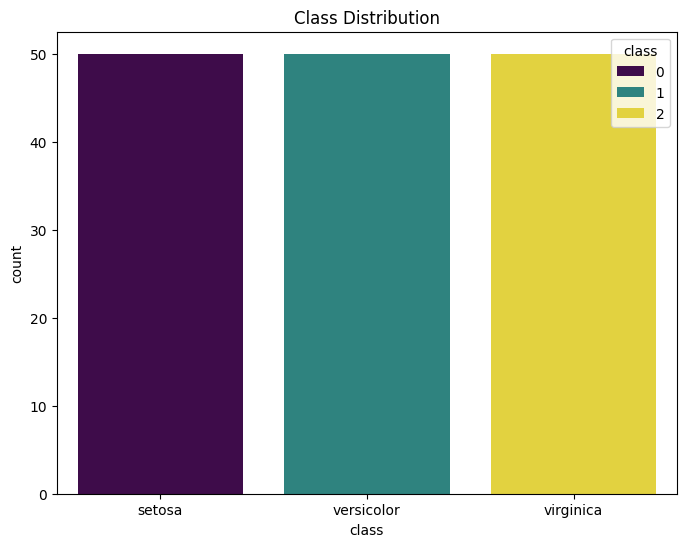

In [44]:
# 클래스별 데이터 분포 확인
plt.figure(figsize=(8, 6))
sns.countplot(x='class', data=df, palette='viridis', hue='class')
plt.title("Class Distribution")
plt.xticks(ticks=[0, 1, 2], labels=class_names)
plt.show()

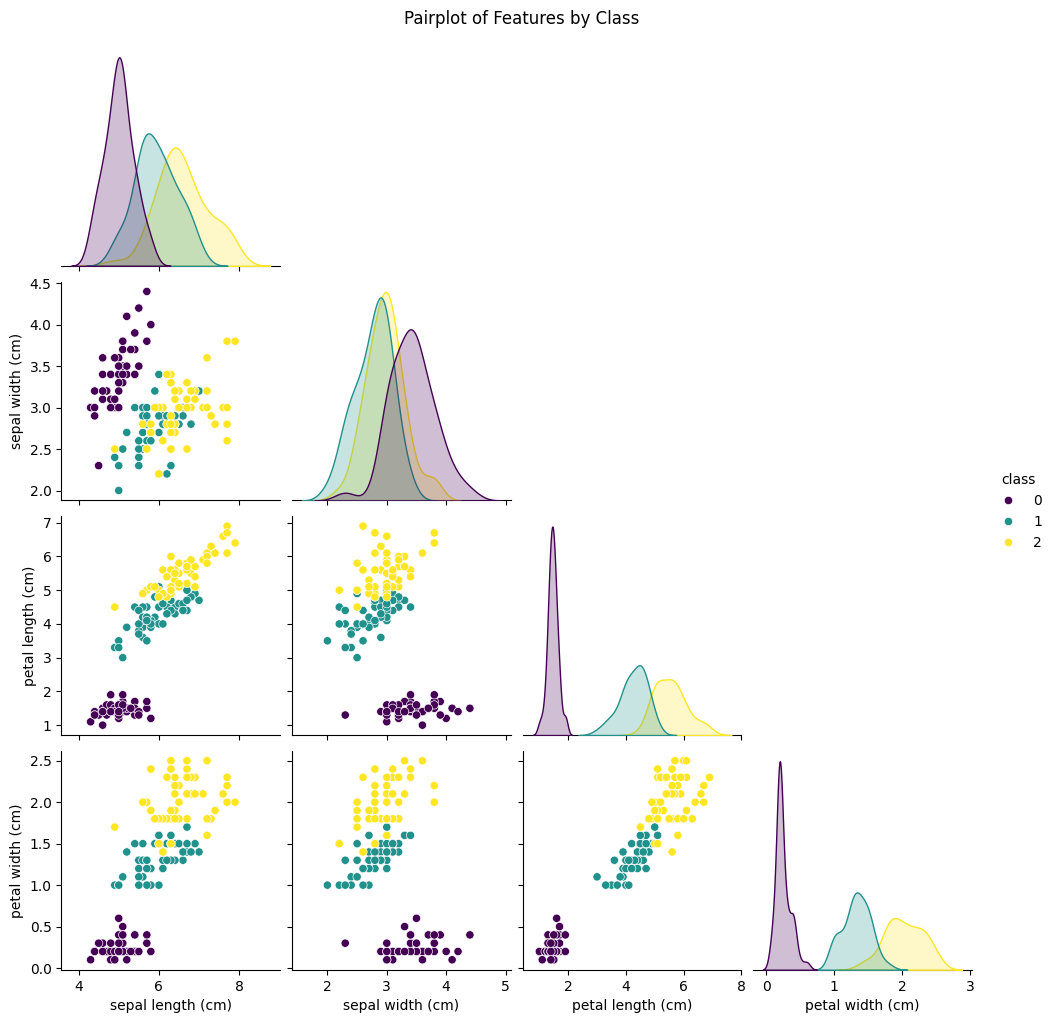

In [45]:
# 피처 간 산점도 행렬
sns.pairplot(df, hue='class', palette='viridis', diag_kind='kde', corner=True)
plt.suptitle("Pairplot of Features by Class", y=1.02)
plt.show()

Pairplot : 피처를 두 개씩 짝지어서 품종별 분포를 보여준다.

그래프를 보면 대체로 setosa(0)은 다른 품종과 잘 분리되고,
veriscolor(1), virginica(2)는 일부 겹친다.

## 2. 데이터 전처리: 데이터 분할 및 스케일링

In [ ]:
# 훈련 데이터와 테스트 데이터 분할
X_train, X_test, y_train, y_test = train_test_split(
    X, 
    y, 
    test_size=0.2, 
    random_state=42, 
    stratify=y)            #stratify=y : train 데이터와 test 데이터에 각 클래스의 비율이 비슷하게 유지되도록 나누는 옵션

# 스케일링 하지 않고 학습한 경우를 비교하기 위해 원본 데이터 따로 저장
X_train_raw, X_test_raw, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y)

In [49]:
# Q2: stratify를 제외하면 클래스 비율이 어떻게 달라질까요? 확인해 보세요.

# stratify를 사용하지 않고 데이터 분할
X_train_no_strat, X_test_no_strat, y_train_no_strat, y_test_no_strat = (
    train_test_split(
        X,
        y,
        test_size=0.2,
        random_state=42))

print("With stratify - Train:", np.bincount(y_train, minlength=3))

print("With stratify - Test:", np.bincount(y_test, minlength=3))

print("Without stratify - Train:", np.bincount(y_train_no_strat, minlength=3))

print("Without stratify - Test:", np.bincount(y_test_no_strat, minlength=3))

With stratify - Train: [40 40 40]
With stratify - Test: [10 10 10]
Without stratify - Train: [40 41 39]
Without stratify - Test: [10  9 11]


stratify를 사용하지 않았더니, 무작위로 나눠져 클래스별 개수가 조금씩 달라졌다.

In [53]:
# 스케일링(표준화)
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

In [51]:
# Q3: 스케일링을 하지 않고 학습하면 정확도에 어떤 영향을 미칠까요?

# 스케일링한 데이터로 모델 학습
scaled_model = SVC(kernel='linear', C=0.1)
scaled_model.fit(X_train, y_train)
scaled_pred = scaled_model.predict(X_test)

scaled_accuracy = accuracy_score(y_test, scaled_pred)


# 스케일링하지 않은 원본 데이터로 모델 학습
unscaled_model = SVC(kernel='linear', C=0.1)
unscaled_model.fit(X_train_raw, y_train)
unscaled_pred = unscaled_model.predict(X_test_raw)

unscaled_accuracy = accuracy_score(y_test, unscaled_pred)


print(f"Scaled Accuracy: {scaled_accuracy:.2f}")

print(f"Unscaled Accuracy: {unscaled_accuracy:.2f}")


Scaled Accuracy: 0.93
Unscaled Accuracy: 0.97


스케일링하지 않은 모델의 정확도가 더 높게 나왔다.
그러나 일반적으로 SVM은 피처의 크기와 거리에 민감하기 때문에 스케일링을 적용하는 것이 권장된다.

## 3. 모델 적합 (SVM)

In [63]:
model = SVC(kernel='linear', C=0.1)  # 선형 커널 사용
model.fit(X_train, y_train);  # 모델 학습

In [60]:
# Q4: C 값을 조정해보세요 (예: 0.1, 10). 모델의 성능에 어떤 영향을 미칠까요?

# C 값별 결과를 저장할 리스트
c_results = []

# 여러 C 값으로 모델 학습
for c_value in [0.01, 0.1, 1, 10, 100]:

    svc_model = SVC(kernel='linear', C=c_value)

    svc_model.fit(X_train, y_train)

    train_pred = svc_model.predict(X_train)
    test_pred = svc_model.predict(X_test)

    c_results.append({
        'C': c_value,
        'Train Accuracy': accuracy_score(
            y_train,
            train_pred
        ),
        'Test Accuracy': accuracy_score(
            y_test,
            test_pred
        )
    })

c_result_df = pd.DataFrame(c_results)

print(c_result_df)

        C  Train Accuracy  Test Accuracy
0    0.01        0.891667       0.866667
1    0.10        0.975000       0.933333
2    1.00        0.975000       1.000000
3   10.00        0.975000       0.966667
4  100.00        0.983333       1.000000


c : train 데이터의 오분류를 얼마나 엄격하게 볼지 
-> c가 작을수록 train 데이터 몇 개 틀리는 것을 허용하고, 
   클수록 train 데이터의 오분류에 강한 penalty를 준다.

c를 0.01부터 100까지 10배씩 키워가며 정확도를 비교해 본 결과,
c가 증가할수록 test 정확도가 항상 증가하는 것은 아니었다.

지나치게 큰 c는 train 데이터에 대해 과적합이 될 수 있다.

In [61]:
# 테스트 데이터로 예측
y_pred = model.predict(X_test)

## 4. 모델 평가 Evaluation 

In [62]:
# 모델 평가
accuracy = accuracy_score(y_test, y_pred)
print(f"Accuracy: {accuracy:.2f}")

print("\nClassification Report:")
print(classification_report(y_test, y_pred, target_names=iris.target_names))

Accuracy: 0.93

Classification Report:
              precision    recall  f1-score   support

      setosa       1.00      1.00      1.00        10
  versicolor       0.90      0.90      0.90        10
   virginica       0.90      0.90      0.90        10

    accuracy                           0.93        30
   macro avg       0.93      0.93      0.93        30
weighted avg       0.93      0.93      0.93        30



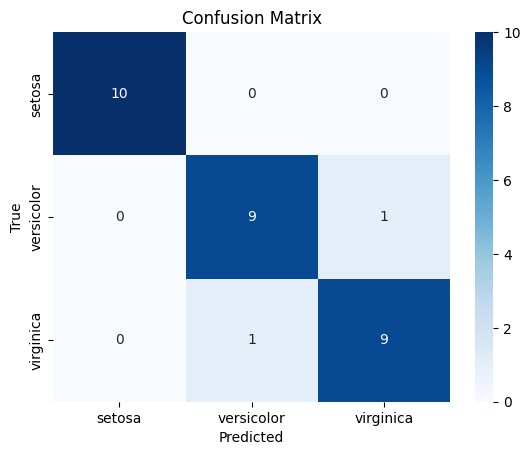

In [64]:
# Confusion Matrix 시각화
cm = confusion_matrix(y_test, y_pred)
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", xticklabels=iris.target_names, yticklabels=iris.target_names)
plt.xlabel("Predicted")
plt.ylabel("True")
plt.title("Confusion Matrix")
plt.show()

In [ ]:
# Q6: Confusion Matrix를 보고 결과를 해석해보세요.

행 : True 실제 클래스
열 : Predicted 모델이 예측한 클래스

# 1행 [10 0 0]
실제 setosa 10개를 전부 setosa로 맞혔다.

# 2행 [0 9 1]
실제 veriscolor 10개 중에 9개는 정확히 예측했고, 1개는 virginica로 잘못 예측했다.

# 3행 [0 1 9]
실제 virginica 10개 중에 1개는 veriscolor로 잘못 예측했고, 9개는 정확히 예측했다.

따라서 전체 30개 중 28개를 올바르게 분류하여 정확도는 28/30 = 약 93.3%이다.

이전의 pariplot에서도 setosa는 다른 품종과 확실히 분리되었지만, 
veriscolor과 virginica는 일부 겹치는 분포를 확인할 수 있었다.

# Precision : 예측한 것 중에 실제로 맞힌 비율
- setosa : 10/10 = 1
- veriscolor : 9/10 = 0.9
- virginica : 9/10 = 0.9

# Recall(Sensitivity) : 실제로 해당 품종인 것 중, 모델이 해당 품종이라고 찾아낸 비율
- setosa : 10/10 = 1
- veriscolor : 9/10 = 0.9
- virginica : 9/10 = 0.9

# Specificity : 실제로 해당 품종이 아닌 것 중, 모델이 해당 품종이 아니라고 찾아낸 비율
- setosa : 20/20 = 1
- veriscolor : 19/20 = 0.95
- virginica : 19/20 = 0.95

전체적으로 높은 분류 성능을 보이지만, 
veriscolor과 virginica 사이에서 각각 1개씩 오분류가 발생하여
두 품종을 구분하는 데 상대적으로 오류가 발생한 것으로 보인다.
